In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv('../Data/HRDataset_v14.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [37]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='str')

In [38]:
df.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [39]:
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')
df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['Tenure_Days'] = (df['DateofTermination'].fillna(pd.Timestamp.now()) - df['DateofHire']).dt.days
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], format='%m/%d/%y', errors='coerce')
df['DateofHire'] = pd.to_datetime(df['DateofHire'], format='%m/%d/%y', errors='coerce')

In [40]:
df['Position'].unique()

<StringArray>
[     'Production Technician I',                      'Sr. DBA',
     'Production Technician II',            'Software Engineer',
                   'IT Support',                 'Data Analyst',
       'Database Administrator',         'Enterprise Architect',
               'Sr. Accountant',           'Production Manager',
                 'Accountant I',           'Area Sales Manager',
 'Software Engineering Manager',                  'BI Director',
       'Director of Operations',         'Sr. Network Engineer',
                'Sales Manager',                 'BI Developer',
         'IT Manager - Support',             'Network Engineer',
                  'IT Director',            'Director of Sales',
     'Administrative Assistant',              'President & CEO',
          'Senior BI Developer',      'Shared Services Manager',
           'IT Manager - Infra',     'Principal Data Architect',
               'Data Architect',              'IT Manager - DB',
           

Typo in 'Data Analyst '

In [41]:
df['Position'] = df['Position'].str.strip()

# NaNs

In [42]:
df.isna().sum()[df.isna().sum() > 0]

DateofTermination    207
ManagerID              8
dtype: int64

In [43]:
df.isna().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

So many NaN values in 'DateofTermination' likely means that those employer are still active

In [44]:
df['DateofTermination'] = df['DateofTermination'].fillna('Active')

In [45]:
df['Position'].unique()

<StringArray>
[     'Production Technician I',                      'Sr. DBA',
     'Production Technician II',            'Software Engineer',
                   'IT Support',                 'Data Analyst',
       'Database Administrator',         'Enterprise Architect',
               'Sr. Accountant',           'Production Manager',
                 'Accountant I',           'Area Sales Manager',
 'Software Engineering Manager',                  'BI Director',
       'Director of Operations',         'Sr. Network Engineer',
                'Sales Manager',                 'BI Developer',
         'IT Manager - Support',             'Network Engineer',
                  'IT Director',            'Director of Sales',
     'Administrative Assistant',              'President & CEO',
          'Senior BI Developer',      'Shared Services Manager',
           'IT Manager - Infra',     'Principal Data Architect',
               'Data Architect',              'IT Manager - DB',
           

In [46]:
df[df['ManagerID'].isna()].groupby('Position').size()

Position
Production Technician I     4
Production Technician II    4
dtype: int64

In [47]:
managersI = df[df['Position'] == 'Production Technician I']['ManagerID'].unique()
print(managersI)

[22. 16. 39. 11. 19. 12. 14. 20. 18. nan]


In [48]:
managersII = df[df['Position'] == 'Production Technician II']['ManagerID'].unique()
print(managersII)

[20. 18. 22. 16. nan 11. 19. 12. 14. 30. 39.]


Impossible to impute the correct 'ManagerID'. Those 8 rows will be dropped

In [49]:
df = df.dropna(subset=['ManagerID'])

In [50]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

All good!

# Outliers

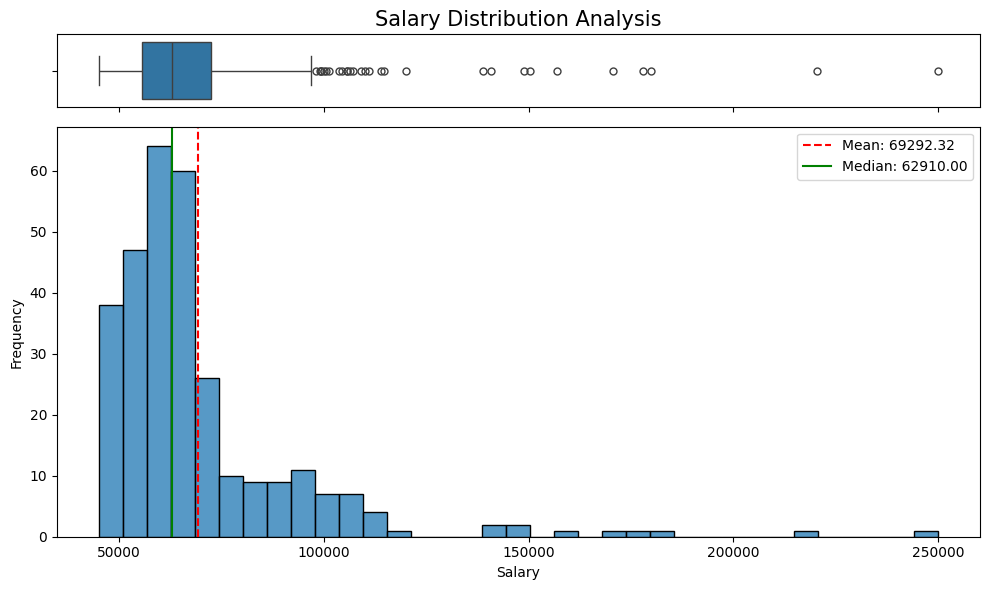

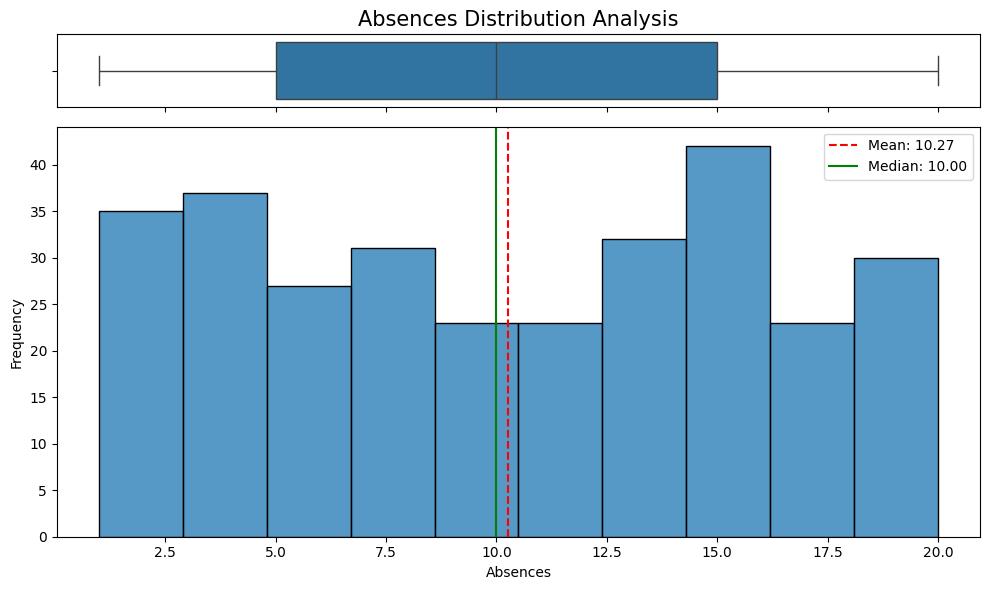

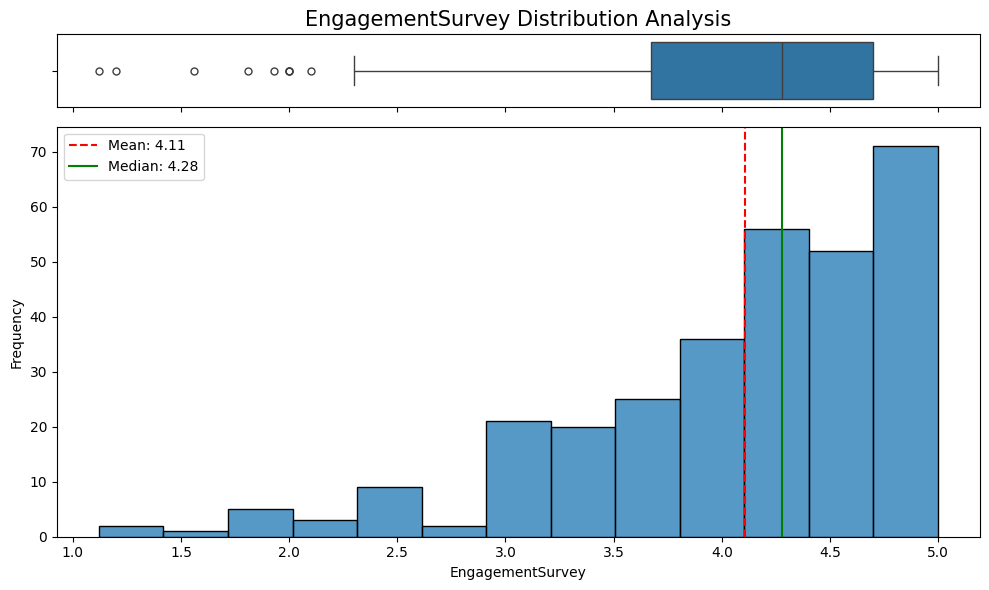

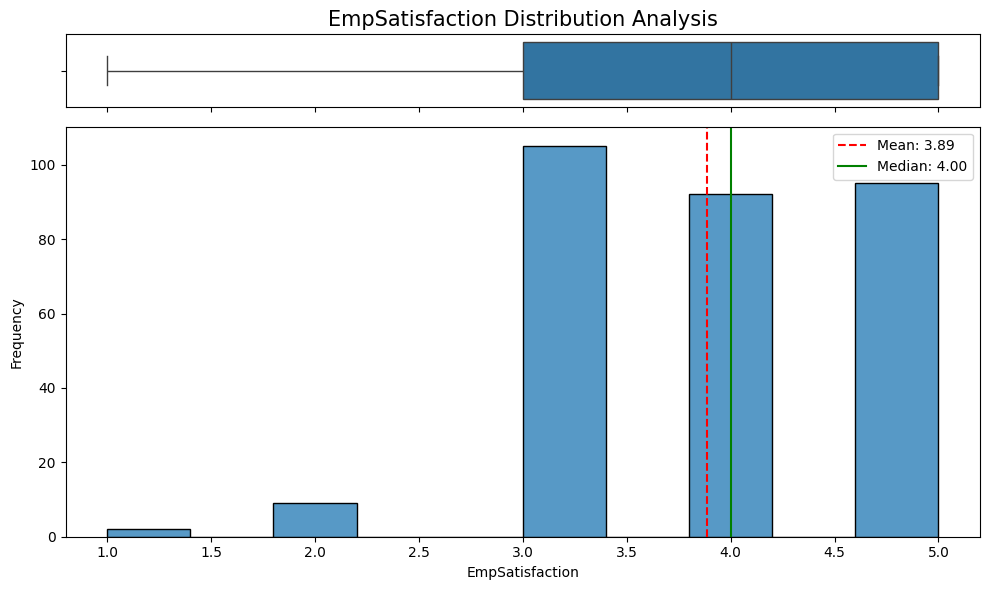

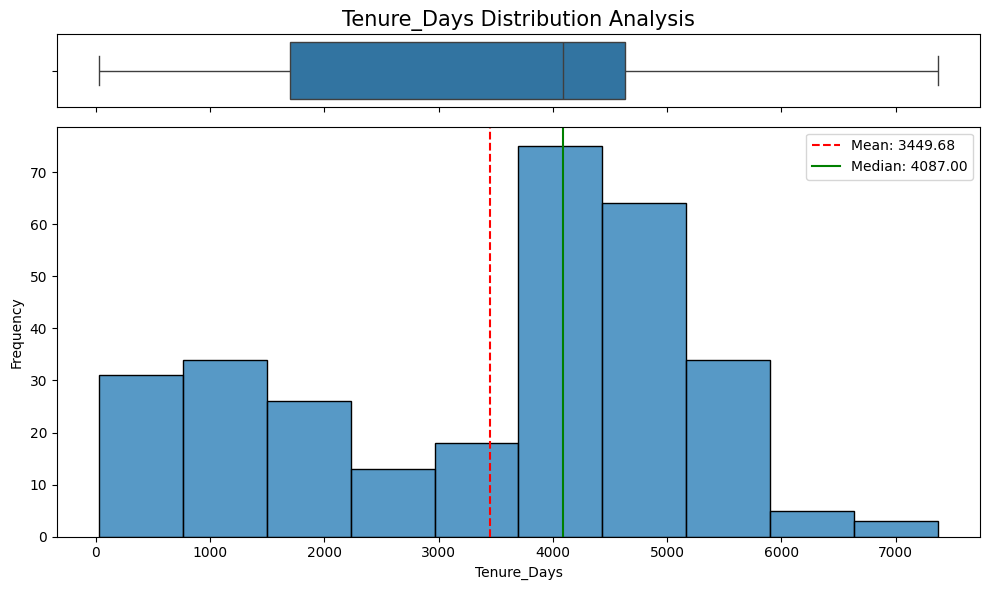

In [52]:
cols_to_plot = ['Salary', 'Absences', 'EngagementSurvey', 'EmpSatisfaction', 'Tenure_Days']

for col in cols_to_plot:
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                        gridspec_kw={"height_ratios": (.15, .85)}, 
                                        figsize=(10, 6))

    sns.boxplot(x=df[col], ax=ax_box, fliersize=5)
    ax_box.set(xlabel='')
    ax_box.set_title(f'{col} Distribution Analysis', fontsize=15)

    sns.histplot(df[col], ax=ax_hist)
    ax_hist.set(xlabel=col, ylabel='Frequency')

    plt.axvline(df[col].mean(), color='red', linestyle='--', label=f"Mean: {df[col].mean():.2f}")
    plt.axvline(df[col].median(), color='green', linestyle='-', label=f"Median: {df[col].median():.2f}")
    plt.legend()

    plt.tight_layout()
    plt.show()

Salaries and engagement have outliers, but they should not be removed